<a href="https://colab.research.google.com/github/aparna-2001/nifty50-stock-price-forecasting/blob/mi-feature-selection/Copy_of_nifty50_monthly_eda_prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os, sys

if not os.path.exists('/content/nifty50-stock-price-forecasting'):
    !git clone https://github.com/aparna-2001/nifty50-stock-price-forecasting.git

sys.path.append('/content/nifty50-stock-price-forecasting')


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from mutual_information import mi_feature_selection_pipeline



In [24]:
nifty_df = pd.read_csv('nifty50_25years_ohlcv_1999_2026.csv')

In [25]:
nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6286 entries, 0 to 6285
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6286 non-null   object 
 1   Open    6286 non-null   float64
 2   High    6286 non-null   float64
 3   Low     6286 non-null   float64
 4   Close   6286 non-null   float64
 5   Volume  6286 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 294.8+ KB


* Aggreggating it to monthly data

In [26]:
nifty_df = pd.read_csv('nifty50_25years_ohlcv_1999_2026.csv', parse_dates=['Date'])

In [27]:
df = pd.read_csv('nifty50_25years_ohlcv_1999_2026.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

monthly = df.resample('MS').agg(
    Month_Open  = ('Open',  'first'),
    Month_Close = ('Close', 'last'),
    Month_High  = ('High',  'max'),
    Month_Low   = ('Low',   'min'),
    Avg_Volume  = ('Volume','mean')
).reset_index()

monthly.rename(columns={'Date': 'Month'}, inplace=True)

# Check which months are missing
print(monthly[monthly['Month_Close'].isnull()][['Month']])

# Drop missing months
monthly.dropna(inplace=True)
print(monthly.shape)
print(monthly.dtypes)

         Month
49  2003-02-01
50  2003-03-01
51  2003-04-01
52  2003-05-01
53  2003-06-01
54  2003-07-01
55  2003-08-01
56  2003-09-01
57  2003-10-01
58  2003-11-01
59  2003-12-01
96  2007-01-01
97  2007-02-01
98  2007-03-01
99  2007-04-01
100 2007-05-01
101 2007-06-01
102 2007-07-01
103 2007-08-01
(308, 6)
Month          datetime64[ns]
Month_Open            float64
Month_Close           float64
Month_High            float64
Month_Low             float64
Avg_Volume            float64
dtype: object


In [28]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 326
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        308 non-null    datetime64[ns]
 1   Month_Open   308 non-null    float64       
 2   Month_Close  308 non-null    float64       
 3   Month_High   308 non-null    float64       
 4   Month_Low    308 non-null    float64       
 5   Avg_Volume   308 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 16.8 KB


*checking for stationarity*

*feature engineering*

In [29]:
monthly['Monthly_Return_%']  = (monthly['Month_Close'] - monthly['Month_Open']) / monthly['Month_Open'] * 100
monthly['HL_Range_%']        = (monthly['Month_High']  - monthly['Month_Low'])   / monthly['Month_Open'] * 100
monthly['Body_Ratio']        = abs(monthly['Month_Close'] - monthly['Month_Open']) / (monthly['Month_High'] - monthly['Month_Low'])
monthly['Upper_Shadow_%']    = (monthly['Month_High'] - monthly[['Month_Open','Month_Close']].max(axis=1)) / monthly['Month_Open'] * 100
monthly['Lower_Shadow_%']    = (monthly[['Month_Open','Month_Close']].min(axis=1) - monthly['Month_Low'])  / monthly['Month_Open'] * 100
monthly['Recovery_Rate_%'] = (monthly['Month_Close'] - monthly['Month_Low']) / (monthly['Month_High'] - monthly['Month_Low']) * 100

In [30]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 326
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Month             308 non-null    datetime64[ns]
 1   Month_Open        308 non-null    float64       
 2   Month_Close       308 non-null    float64       
 3   Month_High        308 non-null    float64       
 4   Month_Low         308 non-null    float64       
 5   Avg_Volume        308 non-null    float64       
 6   Monthly_Return_%  308 non-null    float64       
 7   HL_Range_%        308 non-null    float64       
 8   Body_Ratio        308 non-null    float64       
 9   Upper_Shadow_%    308 non-null    float64       
 10  Lower_Shadow_%    308 non-null    float64       
 11  Recovery_Rate_%   308 non-null    float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 31.3 KB


In [31]:
# Target variable
monthly['Next_Month_Return_%'] = monthly['Monthly_Return_%'].shift(-1)
monthly['Next_Month_Direction'] = (monthly['Next_Month_Return_%'] > 0).astype(int)

# Drop last row (NaN target after shift)
monthly = monthly.dropna(subset=['Next_Month_Return_%'])

print(monthly[['Month', 'Monthly_Return_%', 'Next_Month_Return_%', 'Next_Month_Direction']].tail())
print(f"\nShape: {monthly.shape}")
print(f"Direction balance: {monthly['Next_Month_Direction'].value_counts().to_dict()}")

         Month  Monthly_Return_%  Next_Month_Return_%  Next_Month_Direction
321 2025-10-01          4.474103             1.969501                     1
322 2025-11-01          1.969501            -0.745281                     0
323 2025-12-01         -0.745281            -3.257711                     0
324 2026-01-01         -3.257711             1.541146                     1
325 2026-02-01          1.541146             0.837208                     1

Shape: (307, 14)
Direction balance: {1: 176, 0: 131}


In [32]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307 entries, 0 to 325
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 307 non-null    datetime64[ns]
 1   Month_Open            307 non-null    float64       
 2   Month_Close           307 non-null    float64       
 3   Month_High            307 non-null    float64       
 4   Month_Low             307 non-null    float64       
 5   Avg_Volume            307 non-null    float64       
 6   Monthly_Return_%      307 non-null    float64       
 7   HL_Range_%            307 non-null    float64       
 8   Body_Ratio            307 non-null    float64       
 9   Upper_Shadow_%        307 non-null    float64       
 10  Lower_Shadow_%        307 non-null    float64       
 11  Recovery_Rate_%       307 non-null    float64       
 12  Next_Month_Return_%   307 non-null    float64       
 13  Next_Month_Direction  307

*plotting monthly opening and closing prices*

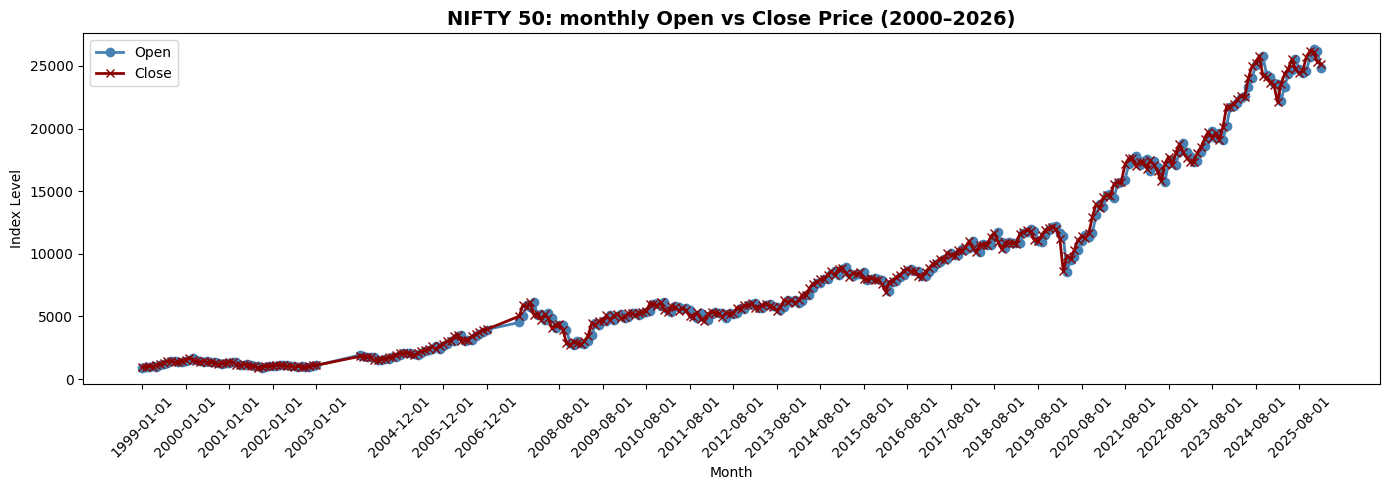

In [33]:
plt.figure(figsize=(14, 5))
plt.plot(monthly['Month'], monthly['Month_Open'],  label='Open',  marker='o', color='steelblue', linewidth=2)
plt.plot(monthly['Month'], monthly['Month_Close'], label='Close', marker='x', color='darkred',   linewidth=2)

plt.title('NIFTY 50: monthly Open vs Close Price (2000–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Index Level')
plt.xticks(monthly['Month'][::12], rotation=45)  # one tick per year
plt.legend()
plt.tight_layout()
plt.show()

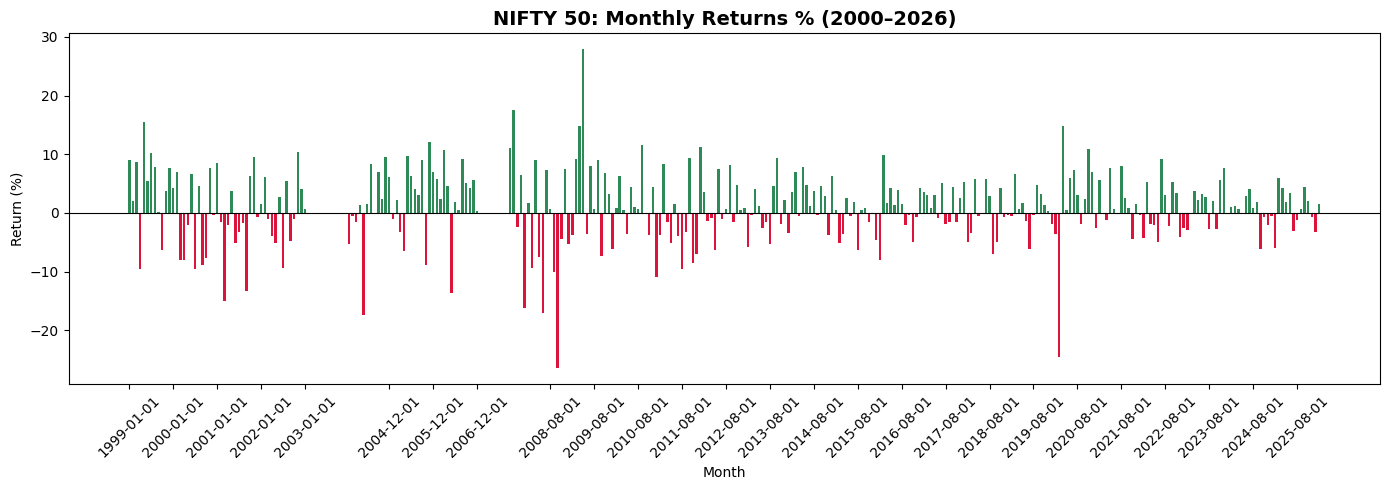

In [34]:
plt.figure(figsize=(14, 5))
plt.bar(monthly['Month'], monthly['Monthly_Return_%'],
        color=monthly['Monthly_Return_%'].apply(lambda x: 'seagreen' if x > 0 else 'crimson'),
        width=20)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('NIFTY 50: Monthly Returns % (2000–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Return (%)')
plt.xticks(monthly['Month'][::12], rotation=45)
plt.tight_layout()
plt.show()

*feature engineering of previous bull return % and previous bear return %

In [35]:
monthly['Bull_Return_%'] = monthly['Monthly_Return_%'].clip(lower=0)  # green months only, 0 for red
monthly['Bear_Return_%'] = monthly['Monthly_Return_%'].clip(upper=0)  # red months only, 0 for green


monthly['Prev_Bull_Return_%'] = monthly['Bull_Return_%'].shift(1)
monthly['Prev_Bear_Return_%'] = monthly['Bear_Return_%'].shift(1)

In [36]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307 entries, 0 to 325
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 307 non-null    datetime64[ns]
 1   Month_Open            307 non-null    float64       
 2   Month_Close           307 non-null    float64       
 3   Month_High            307 non-null    float64       
 4   Month_Low             307 non-null    float64       
 5   Avg_Volume            307 non-null    float64       
 6   Monthly_Return_%      307 non-null    float64       
 7   HL_Range_%            307 non-null    float64       
 8   Body_Ratio            307 non-null    float64       
 9   Upper_Shadow_%        307 non-null    float64       
 10  Lower_Shadow_%        307 non-null    float64       
 11  Recovery_Rate_%       307 non-null    float64       
 12  Next_Month_Return_%   307 non-null    float64       
 13  Next_Month_Direction  307

In [37]:
monthly = monthly.dropna(subset=['Prev_Bull_Return_%', 'Prev_Bear_Return_%'])
print(monthly.shape)  # should be (306, 18)

(306, 18)


In [38]:
monthly['Rolling_CAGR_%'] = (
    monthly['Month_Close']
    .pct_change(12)  # 12-month rolling return
    * 100
)

monthly = monthly.dropna(subset=['Rolling_CAGR_%'])
print(monthly.shape)

(294, 19)


In [39]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 13 to 325
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 294 non-null    datetime64[ns]
 1   Month_Open            294 non-null    float64       
 2   Month_Close           294 non-null    float64       
 3   Month_High            294 non-null    float64       
 4   Month_Low             294 non-null    float64       
 5   Avg_Volume            294 non-null    float64       
 6   Monthly_Return_%      294 non-null    float64       
 7   HL_Range_%            294 non-null    float64       
 8   Body_Ratio            294 non-null    float64       
 9   Upper_Shadow_%        294 non-null    float64       
 10  Lower_Shadow_%        294 non-null    float64       
 11  Recovery_Rate_%       294 non-null    float64       
 12  Next_Month_Return_%   294 non-null    float64       
 13  Next_Month_Direction  29

In [40]:
feature_cols = [
    'Monthly_Return_%',
    'HL_Range_%',
    'Body_Ratio',
    'Upper_Shadow_%',
    'Lower_Shadow_%',
    'Recovery_Rate_%',
    'Prev_Bull_Return_%',
    'Prev_Bear_Return_%',
    'Rolling_CAGR_%',
    'Avg_Volume'
]

📊 Computing Mutual Information (regression)...

📋 Top Features by MI Score:
           Feature  MI_Score  Normalized_MI  Rank
    Rolling_CAGR_%  0.071854       1.000000     1
    Upper_Shadow_%  0.058798       0.818297     2
   Recovery_Rate_%  0.050792       0.706885     3
  Monthly_Return_%  0.029476       0.410227     4
        Avg_Volume  0.020224       0.281465     5
Prev_Bull_Return_%  0.016090       0.223932     6
        HL_Range_%  0.012770       0.177719     7
Prev_Bear_Return_%  0.002882       0.040115     8


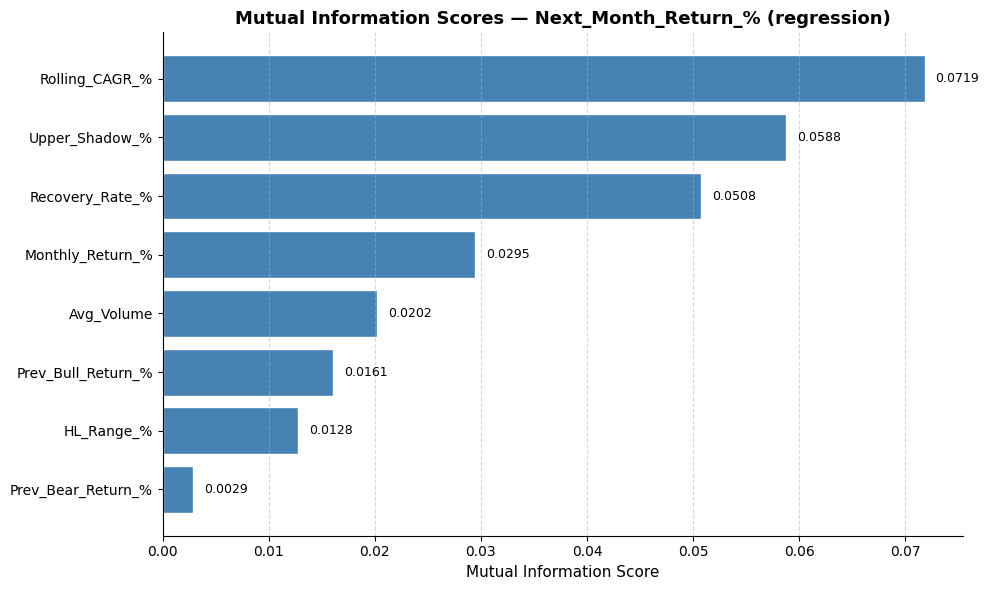


✅ Selected 8 features:
   1. Rolling_CAGR_%  →  MI Score: 0.0719
   2. Upper_Shadow_%  →  MI Score: 0.0588
   3. Recovery_Rate_%  →  MI Score: 0.0508
   4. Monthly_Return_%  →  MI Score: 0.0295
   5. Avg_Volume  →  MI Score: 0.0202
   6. Prev_Bull_Return_%  →  MI Score: 0.0161
   7. HL_Range_%  →  MI Score: 0.0128
   8. Prev_Bear_Return_%  →  MI Score: 0.0029
📊 Computing Mutual Information (classification)...

📋 Top Features by MI Score:
           Feature  MI_Score  Normalized_MI  Rank
    Lower_Shadow_%  0.055199       1.000000     1
    Rolling_CAGR_%  0.049896       0.903924     2
    Upper_Shadow_%  0.020862       0.377944     3
Prev_Bull_Return_%  0.010278       0.186205     4
        Avg_Volume  0.002910       0.052710     5
   Recovery_Rate_%  0.002481       0.044940     6
        HL_Range_%  0.000000       0.000000     7
  Monthly_Return_%  0.000000       0.000000     8


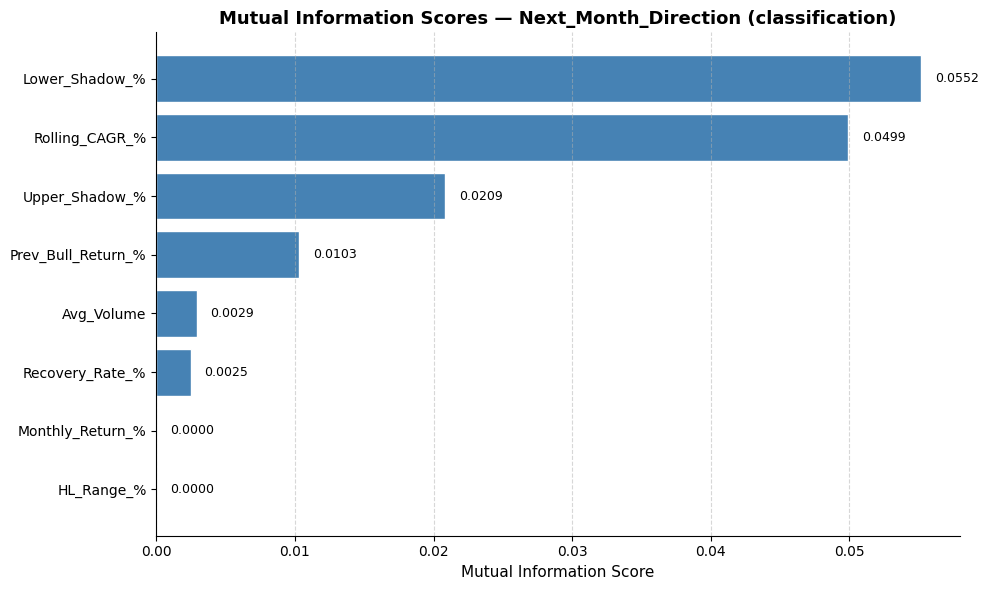


✅ Selected 8 features:
   1. Lower_Shadow_%  →  MI Score: 0.0552
   2. Rolling_CAGR_%  →  MI Score: 0.0499
   3. Upper_Shadow_%  →  MI Score: 0.0209
   4. Prev_Bull_Return_%  →  MI Score: 0.0103
   5. Avg_Volume  →  MI Score: 0.0029
   6. Recovery_Rate_%  →  MI Score: 0.0025
   7. HL_Range_%  →  MI Score: 0.0000
   8. Monthly_Return_%  →  MI Score: 0.0000
Top Regression Features: ['Rolling_CAGR_%', 'Upper_Shadow_%', 'Recovery_Rate_%', 'Monthly_Return_%', 'Avg_Volume', 'Prev_Bull_Return_%', 'HL_Range_%', 'Prev_Bear_Return_%']
Top Classification Features: ['Lower_Shadow_%', 'Rolling_CAGR_%', 'Upper_Shadow_%', 'Prev_Bull_Return_%', 'Avg_Volume', 'Recovery_Rate_%', 'HL_Range_%', 'Monthly_Return_%']


In [41]:
mi_df_reg, top_reg_features = mi_feature_selection_pipeline(
    monthly[feature_cols + ['Next_Month_Return_%']],
    'Next_Month_Return_%', task='regression', top_n=8, plot=True
)

mi_df_clf, top_clf_features = mi_feature_selection_pipeline(
    monthly[feature_cols + ['Next_Month_Direction']],
    'Next_Month_Direction', task='classification', top_n=8, plot=True
)

print("Top Regression Features:", top_reg_features)
print("Top Classification Features:", top_clf_features)

*baseline feature*

In [22]:
# MI-selected baseline features
top_reg_features = [
    'Rolling_CAGR_%', 'Upper_Shadow_%', 'Recovery_Rate_%',
    'Monthly_Return_%', 'Avg_Volume', 'Prev_Bull_Return_%', 'HL_Range_%'
]

top_clf_features = [
    'Lower_Shadow_%', 'Rolling_CAGR_%', 'Upper_Shadow_%', 'Prev_Bull_Return_%'
]

# Regression split
X_reg = monthly[top_reg_features]
y_reg = monthly['Next_Month_Return_%']

split = int(len(monthly) * 0.8)
X_reg_train, X_reg_test = X_reg.iloc[:split], X_reg.iloc[split:]
y_reg_train, y_reg_test = y_reg.iloc[:split], y_reg.iloc[split:]

# Classification split
X_clf = monthly[top_clf_features]
y_clf = monthly['Next_Month_Direction']

X_clf_train, X_clf_test = X_clf.iloc[:split], X_clf.iloc[split:]
y_clf_train, y_clf_test = y_clf.iloc[:split], y_clf.iloc[split:]

**Regression models using Random Forest, XGBoost**

In [42]:
models_reg = {
    'Ridge':         Ridge(),
    'RandomForest':  RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':       XGBRegressor(n_estimators=100, random_state=42)
}



**Classification models using Logistic regression, Random forest, XGBoost**

In [43]:
models_clf = {
    'LogisticReg':   LogisticRegression(),
    'RandomForest':  RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':       XGBClassifier(n_estimators=100, random_state=42)
}



**Summary of models**

In [45]:
print("=== REGRESSION ===")
for name, model in models_reg.items():
    model.fit(X_reg_train, y_reg_train)
    pred = model.predict(X_reg_test)
    print(f"{name:15} MAE: {mean_absolute_error(y_reg_test, pred):.3f}  RMSE: {root_mean_squared_error(y_reg_test, pred):.3f}")

print("\n=== CLASSIFICATION ===")
for name, model in models_clf.items():
    model.fit(X_clf_train, y_clf_train)
    pred = model.predict(X_clf_test)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf_test, pred):.3f}  F1: {f1_score(y_clf_test, pred):.3f}")

=== REGRESSION ===
Ridge           MAE: 2.843  RMSE: 3.577
RandomForest    MAE: 3.182  RMSE: 4.039
XGBoost         MAE: 3.760  RMSE: 4.781

=== CLASSIFICATION ===
LogisticReg     Accuracy: 0.559  F1: 0.629
RandomForest    Accuracy: 0.627  F1: 0.667
XGBoost         Accuracy: 0.644  F1: 0.687


* Ridge has the lowest MAE and RMSE

* Accuracy is higher for XGBoost followed by Random forest

* It is worth noticing that F1 score is most higher for Logistic regression.


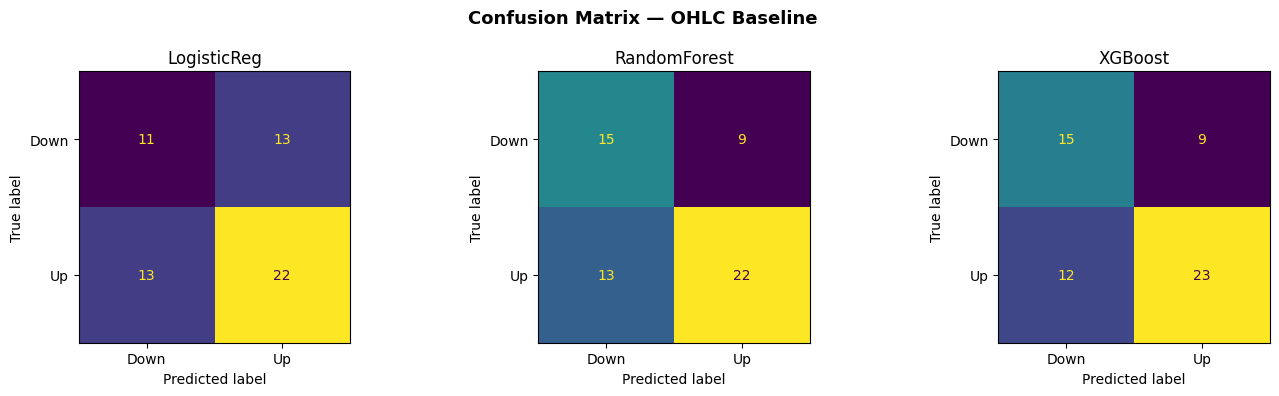

In [47]:


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models_clf.items()):
    pred = model.predict(X_clf_test)
    cm = confusion_matrix(y_clf_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrix — OHLC Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Overall false pedictions only differ by one.
* logistic regression ; false prediction 24,
* random forest 23 and xgboost 22.
* so xgboost is better
* Logistic regression only provides up details

## Macro economic effects

In [48]:


crude = yf.download('CL=F',  start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
gold  = yf.download('GC=F',  start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
usdinr= yf.download('INR=X', start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()

macro = pd.DataFrame({
    'Crude': crude,
    'Gold': gold,
    'USDINR': usdinr
}).reset_index().rename(columns={'index': 'Month'})

# Compute % changes
macro['Crude_Change_%']      = macro['Crude'].pct_change()  * 100
macro['Gold_Change_%']       = macro['Gold'].pct_change()   * 100
macro['USDINR_Change_%']     = macro['USDINR'].pct_change() * 100
macro['Prev_Crude_Change_%'] = macro['Crude_Change_%'].shift(1)
macro['Prev_Gold_Change_%']   = macro['Gold_Change_%'].shift(1)
macro['Prev_USDINR_Change_%'] = macro['USDINR_Change_%'].shift(1)

print(macro.shape)
print(macro.isnull().sum())

/tmp/ipykernel_1837/3010929040.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crude = yf.download('CL=F',  start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1837/3010929040.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold  = yf.download('GC=F',  start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1837/3010929040.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdinr= yf.download('INR=X', start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
[*********************100%***********************]  1 of 1 completed


(307, 10)
Date                     0
Crude                    0
Gold                     0
USDINR                  40
Crude_Change_%           1
Gold_Change_%            1
USDINR_Change_%         41
Prev_Crude_Change_%      2
Prev_Gold_Change_%       2
Prev_USDINR_Change_%    42
dtype: int64


In [49]:
# Merging on Month

monthly['Month'] = pd.to_datetime(monthly['Month'])
macro['Date']    = pd.to_datetime(macro['Date'])

monthly_v2 = monthly.merge(
    macro[['Date', 'Crude_Change_%', 'Gold_Change_%',
           'USDINR_Change_%', 'Prev_Crude_Change_%',
           'Prev_Gold_Change_%', 'Prev_USDINR_Change_%']],
    left_on='Month', right_on='Date', how='left'
).drop(columns='Date')


monthly_v2.dropna(inplace=True)
print(monthly_v2.shape)
print(monthly_v2.isnull().sum())

(257, 25)
Month                   0
Month_Open              0
Month_Close             0
Month_High              0
Month_Low               0
Avg_Volume              0
Monthly_Return_%        0
HL_Range_%              0
Body_Ratio              0
Upper_Shadow_%          0
Lower_Shadow_%          0
Recovery_Rate_%         0
Next_Month_Return_%     0
Next_Month_Direction    0
Bull_Return_%           0
Bear_Return_%           0
Prev_Bull_Return_%      0
Prev_Bear_Return_%      0
Rolling_CAGR_%          0
Crude_Change_%          0
Gold_Change_%           0
USDINR_Change_%         0
Prev_Crude_Change_%     0
Prev_Gold_Change_%      0
Prev_USDINR_Change_%    0
dtype: int64


In [50]:
print("Nifty range:  ", monthly['Month'].min(), "→", monthly['Month'].max())
print("Macro range:  ", macro['Date'].min(), "→", macro['Date'].max())
print("Merged shape: ", monthly_v2.shape)
print("Merged range: ", monthly_v2['Month'].min(), "→", monthly_v2['Month'].max())

Nifty range:   2000-02-01 00:00:00 → 2026-02-01 00:00:00
Macro range:   2000-08-01 00:00:00 → 2026-02-01 00:00:00
Merged shape:  (257, 25)
Merged range:  2004-02-01 00:00:00 → 2026-02-01 00:00:00


In [52]:
monthly_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 37 to 293
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 257 non-null    datetime64[ns]
 1   Month_Open            257 non-null    float64       
 2   Month_Close           257 non-null    float64       
 3   Month_High            257 non-null    float64       
 4   Month_Low             257 non-null    float64       
 5   Avg_Volume            257 non-null    float64       
 6   Monthly_Return_%      257 non-null    float64       
 7   HL_Range_%            257 non-null    float64       
 8   Body_Ratio            257 non-null    float64       
 9   Upper_Shadow_%        257 non-null    float64       
 10  Lower_Shadow_%        257 non-null    float64       
 11  Recovery_Rate_%       257 non-null    float64       
 12  Next_Month_Return_%   257 non-null    float64       
 13  Next_Month_Direction  25

In [59]:
feature_cols_v2 = [
    "Monthly_Return_%",
    "HL_Range_%",
    "Body_Ratio",
    "Upper_Shadow_%",
    "Lower_Shadow_%",
    "Recovery_Rate_%",
    "Bull_Return_%",
    "Bear_Return_%",
    "Prev_Bull_Return_%",
    "Prev_Bear_Return_%",
    "Rolling_CAGR_%",
    "Crude_Change_%",
    "Gold_Change_%",
    "USDINR_Change_%",
    "Prev_Crude_Change_%",
    "Prev_Gold_Change_%",
    "Prev_USDINR_Change_%",
]

📊 Computing Mutual Information (regression)...

📋 Top Features by MI Score:
           Feature  MI_Score  Normalized_MI  Rank
    Crude_Change_%  0.127379       1.000000     1
    Rolling_CAGR_%  0.093165       0.731400     2
  Monthly_Return_%  0.074561       0.585347     3
   Recovery_Rate_%  0.065494       0.514166     4
     Gold_Change_%  0.053682       0.421434     5
    Upper_Shadow_%  0.038687       0.303712     6
Prev_Gold_Change_%  0.035985       0.282504     7
     Bull_Return_%  0.031023       0.243547     8


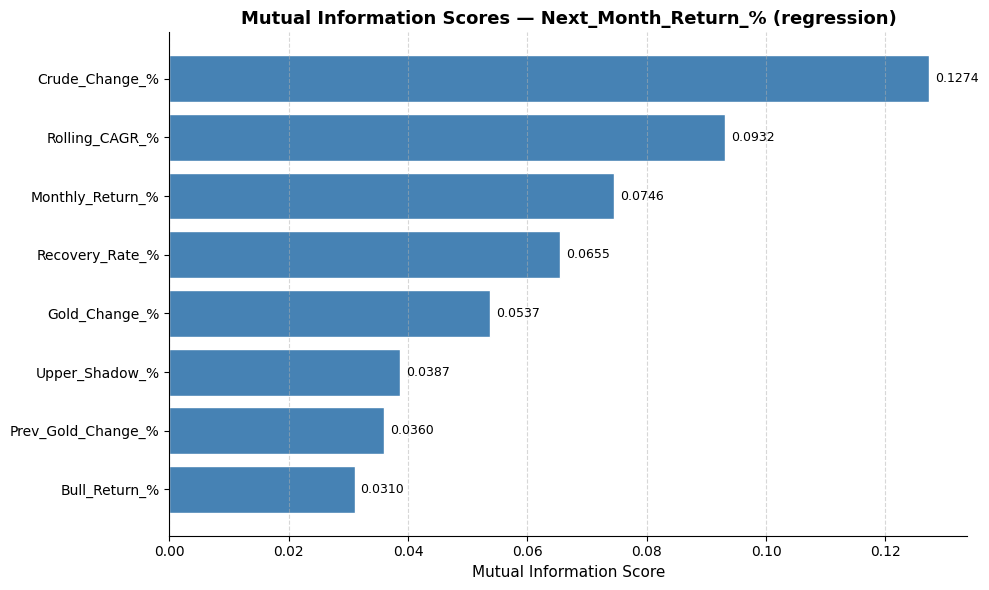


✅ Selected 8 features:
   1. Crude_Change_%  →  MI Score: 0.1274
   2. Rolling_CAGR_%  →  MI Score: 0.0932
   3. Monthly_Return_%  →  MI Score: 0.0746
   4. Recovery_Rate_%  →  MI Score: 0.0655
   5. Gold_Change_%  →  MI Score: 0.0537
   6. Upper_Shadow_%  →  MI Score: 0.0387
   7. Prev_Gold_Change_%  →  MI Score: 0.0360
   8. Bull_Return_%  →  MI Score: 0.0310
📊 Computing Mutual Information (classification)...

📋 Top Features by MI Score:
             Feature  MI_Score  Normalized_MI  Rank
      Rolling_CAGR_%  0.088532       1.000000     1
      Lower_Shadow_%  0.041786       0.471986     2
  Prev_Gold_Change_%  0.035977       0.406371     3
     USDINR_Change_%  0.034524       0.389960     4
     Recovery_Rate_%  0.033455       0.377890     5
Prev_USDINR_Change_%  0.028365       0.320392     6
       Bear_Return_%  0.026526       0.299625     7
  Prev_Bull_Return_%  0.026295       0.297012     8


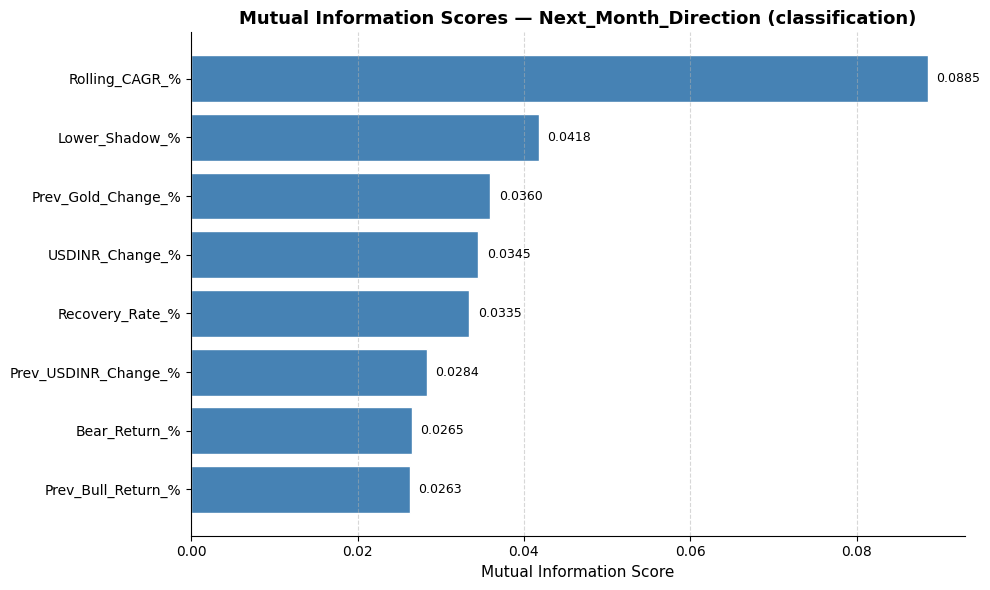


✅ Selected 8 features:
   1. Rolling_CAGR_%  →  MI Score: 0.0885
   2. Lower_Shadow_%  →  MI Score: 0.0418
   3. Prev_Gold_Change_%  →  MI Score: 0.0360
   4. USDINR_Change_%  →  MI Score: 0.0345
   5. Recovery_Rate_%  →  MI Score: 0.0335
   6. Prev_USDINR_Change_%  →  MI Score: 0.0284
   7. Bear_Return_%  →  MI Score: 0.0265
   8. Prev_Bull_Return_%  →  MI Score: 0.0263
Top Regression Features: ['Crude_Change_%', 'Rolling_CAGR_%', 'Monthly_Return_%', 'Recovery_Rate_%', 'Gold_Change_%', 'Upper_Shadow_%', 'Prev_Gold_Change_%', 'Bull_Return_%']
Top Classification Features: ['Rolling_CAGR_%', 'Lower_Shadow_%', 'Prev_Gold_Change_%', 'USDINR_Change_%', 'Recovery_Rate_%', 'Prev_USDINR_Change_%', 'Bear_Return_%', 'Prev_Bull_Return_%']


In [60]:
mi_df_reg, top_reg_features = mi_feature_selection_pipeline(
    monthly_v2[feature_cols_v2 + ['Next_Month_Return_%']],
    'Next_Month_Return_%', task='regression', top_n=8, plot=True
)

mi_df_clf, top_clf_features = mi_feature_selection_pipeline(
    monthly_v2[feature_cols_v2 + ['Next_Month_Direction']],
    'Next_Month_Direction', task='classification', top_n=8, plot=True
)

print("Top Regression Features:", top_reg_features)
print("Top Classification Features:", top_clf_features)

**model with all macro economic factors added to the baseline features**

In [ ]:
feature_cols_v2 = [
    'Monthly_Return_%', 'HL_Range_%', 'Body_Ratio',
    'Upper_Shadow_%', 'Lower_Shadow_%', 'Recovery_Rate_%',
    'Avg_Volume', 'Prev_Bull_Return_%', 'Prev_Bear_Return_%',
    'Rolling_CAGR_%',
    'Crude_Change_%', 'Gold_Change_%', 'USDINR_Change_%', 'Prev_Crude_Change_%',
    'Prev_Gold_Change_%', 'Prev_USDINR_Change_%'
]

In [ ]:
split = int(len(monthly_v2) * 0.8)

X2 = monthly_v2[feature_cols_v2]
y_reg2 = monthly_v2['Next_Month_Return_%']
y_clf2 = monthly_v2['Next_Month_Direction']

X2_train, X2_test = X2.iloc[:split], X2.iloc[split:]
y_reg2_train, y_reg2_test = y_reg2.iloc[:split], y_reg2.iloc[split:]
y_clf2_train, y_clf2_test = y_clf2.iloc[:split], y_clf2.iloc[split:]

print(f"Train: {X2_train.shape}, Test: {X2_test.shape}")

In [ ]:
print("=== REGRESSION (Phase 2) ===")
for name, model in models_reg.items():
    model.fit(X2_train, y_reg2_train)
    pred = model.predict(X2_test)
    print(f"{name:15} MAE: {mean_absolute_error(y_reg2_test, pred):.3f}  RMSE: {root_mean_squared_error(y_reg2_test, pred):.3f}")

print("\n=== CLASSIFICATION (Phase 2) ===")
for name, model in models_clf.items():
    model.fit(X2_train, y_clf2_train)
    pred = model.predict(X2_test)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf2_test, pred):.3f}  F1: {f1_score(y_clf2_test, pred):.3f}")

since the first model is built on different number of dataset than model 2, we can't compare this fairly,

**Model_1b** - *model with same number of dataset as the model2*

In [ ]:
start_date = monthly_v2['Month'].min()
monthly_1b = monthly[monthly['Month'] >= start_date].copy()
print(monthly_1b.shape)  # should be 257

In [ ]:

feature_cols_1b = [
    'Monthly_Return_%', 'HL_Range_%', 'Body_Ratio',
    'Upper_Shadow_%', 'Lower_Shadow_%', 'Recovery_Rate_%',
    'Avg_Volume', 'Prev_Bull_Return_%', 'Prev_Bear_Return_%',
    'Rolling_CAGR_%'
]

X_1b = monthly_1b[feature_cols_1b]
y_reg_1b = monthly_1b['Next_Month_Return_%']
y_clf_1b = monthly_1b['Next_Month_Direction']

split_1b = int(len(monthly_1b) * 0.8)

X_train_1b, X_test_1b = X_1b.iloc[:split_1b], X_1b.iloc[split_1b:]
y_reg_train_1b, y_reg_test_1b = y_reg_1b.iloc[:split_1b], y_reg_1b.iloc[split_1b:]
y_clf_train_1b, y_clf_test_1b = y_clf_1b.iloc[:split_1b], y_clf_1b.iloc[split_1b:]



In [ ]:
models_reg_1b = {
    'Ridge':         Ridge(),
    'RandomForest':  RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':       XGBRegressor(n_estimators=100, random_state=42)
}



In [ ]:
models_clf_1b = {
    'LogisticReg':   LogisticRegression(),
    'RandomForest':  RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':       XGBClassifier(n_estimators=100, random_state=42)
}



In [ ]:
print("=== REGRESSION 1b ===")
for name, model in models_reg_1b.items():
    model.fit(X_train_1b, y_reg_train_1b)
    pred_1b_reg = model.predict(X_test_1b)
    print(f"{name:15} MAE: {mean_absolute_error(y_reg_test_1b, pred_1b_reg):.3f}  RMSE: {root_mean_squared_error(y_reg_test_1b, pred_1b_reg):.3f}")

print("\n=== CLASSIFICATION  1b ===")
for name, model in models_clf_1b.items():
    model.fit(X_train_1b, y_clf_train_1b)
    pred_1b_cl = model.predict(X_test_1b)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf_test_1b, pred_1b_cl):.3f}  F1: {f1_score(y_clf_test_1b, pred_1b_cl):.3f}")

In [ ]:


models_clf_1b_extended = {
    'LogisticReg':    LogisticRegression(),
    'RandomForest':   RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':        XGBClassifier(n_estimators=100, random_state=42),
    'SVM':            SVC(),
    'KNN':            KNeighborsClassifier(),
    'DecisionTree':   DecisionTreeClassifier(random_state=42),
    'NaiveBayes':     GaussianNB()
}

print("=== CLASSIFICATION 1b (Extended) ===")
for name, model in models_clf_1b_extended.items():
    model.fit(X_train_1b, y_clf_train_1b)
    pred = model.predict(X_test_1b)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf_test_1b, pred):.3f}  F1: {f1_score(y_clf_test_1b, pred):.3f}")

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models_clf_1b.items()):
    pred_1b_cl = model.predict(X_test_1b)  # use pred_1b_cl consistently
    cm_1b = confusion_matrix(y_clf_test_1b, pred_1b_cl)
    ConfusionMatrixDisplay(cm_1b, display_labels=['Down', 'Up']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrix — OHLC Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**comparison table of model_1b and model with maccro economic comparison**

## Phase Comparison: OHLC Baseline vs OHLC + Macro (Same 257 rows, 2004–2026)

### Regression (lower is better)
| Model | Phase 1b MAE | Phase 1b RMSE | Phase 2 MAE | Phase 2 RMSE | MAE Δ |
|---|---|---|---|---|---|
| Ridge | 2.858 | 3.480 | 2.982 | 3.625 | ❌ +0.124 |
| Random Forest | 3.049 | 3.986 | 3.134 | 4.003 | ❌ +0.085 |
| XGBoost | 3.811 | 4.709 | 3.384 | 4.232 | ✅ −0.427 |

### Classification (higher is better)
| Model | Phase 1b Acc | Phase 1b F1 | Phase 2 Acc | Phase 2 F1 | Acc Δ |
|---|---|---|---|---|---|
| Logistic Reg | 0.558 | 0.716 | 0.558 | 0.716 | — |
| Random Forest | 0.596 | 0.644 | 0.577 | 0.686 | ❌ −0.019 |
| XGBoost | 0.615 | 0.677 | 0.519 | 0.615 | ❌ −0.096 |

**Findings:** Macro features improve XGBoost regression (−0.427 MAE) but hurt classification.


* This suggest that the prediction of next month is influenced by macro economic features, but the classification( direction) cannot be deduced from this information.

* Also no one classification algorithm shows a pure dominance.

In [ ]:
models_clf_v2_extended = {
    'LogisticReg':    LogisticRegression(),
    'RandomForest':   RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':        XGBClassifier(n_estimators=100, random_state=42),
    'SVM':            SVC(),
    'KNN':            KNeighborsClassifier(),
    'DecisionTree':   DecisionTreeClassifier(random_state=42),
    'NaiveBayes':     GaussianNB()
}

print("=== CLASSIFICATION (Extended) — Phase 2 ===")
for name, model in models_clf_v2_extended.items():
    model.fit(X2_train, y_clf2_train)
    pred = model.predict(X2_test)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf2_test, pred):.3f}  F1: {f1_score(y_clf2_test, pred):.3f}")

* xgboost performs better in 1b baseline classification, while there is no clear dominant performer in classification model involving macro economic features. which means macro economic features add noise to the classification model.

**Important features**

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model, title) in zip(axes, [
    ('XGBoost Regression',     models_reg['XGBoost'],  'XGBoost Regression'),
    ('XGBoost Classification', models_clf['XGBoost'],  'XGBoost Classification')
]):
    importance = pd.Series(model.feature_importances_, index=feature_cols_v2)
    importance.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

* Classification model involving macroeconomic features are harder to predict because no one or few features doesn't have clear dominance in it's prediction

* for regression (monthly prediction of amount) there is a clear hierarchichal dominance of features.

* XGBoost regression clearly shows that the lagged featured of macroeconomic features dominates,

     * top features;
     
           * Rolling CAGR
           * Upper shadow
           * previous crude oil change
           * recovery rate
           * gold change
           * bear return
           * average volume
           * body ratio   etc...

* for classification, removing the macro economic feature will be better, keeping only OHLC features.

**final model for regression**

In [ ]:
feature_cols_final_reg = [
    'Monthly_Return_%', 'HL_Range_%', 'Body_Ratio',
    'Upper_Shadow_%', 'Lower_Shadow_%', 'Recovery_Rate_%',
    'Avg_Volume', 'Prev_Bull_Return_%', 'Prev_Bear_Return_%',
    'Rolling_CAGR_%',
    'Crude_Change_%', 'Gold_Change_%', 'USDINR_Change_%',
    'Prev_Crude_Change_%', 'Prev_Gold_Change_%', 'Prev_USDINR_Change_%'
]

X_reg = monthly_v2[feature_cols_final_reg]
y_reg_f = monthly_v2['Next_Month_Return_%']
split_reg = int(len(monthly_v2) * 0.8)

X_reg_train, X_reg_test = X_reg.iloc[:split_reg], X_reg.iloc[split_reg:]
y_reg_f_train, y_reg_f_test = y_reg_f.iloc[:split_reg], y_reg_f.iloc[split_reg:]

final_reg = XGBRegressor(n_estimators=100, random_state=42)
final_reg.fit(X_reg_train, y_reg_f_train)
pred_reg = final_reg.predict(X_reg_test)

print("=== FINAL REGRESSION ===")
print(f"MAE:  {mean_absolute_error(y_reg_f_test, pred_reg):.3f}")
print(f"RMSE: {root_mean_squared_error(y_reg_f_test, pred_reg):.3f}")

**final model for classification**

In [ ]:
feature_cols_final_clf = [
    'Monthly_Return_%', 'HL_Range_%', 'Body_Ratio',
    'Upper_Shadow_%', 'Lower_Shadow_%', 'Recovery_Rate_%',
    'Avg_Volume', 'Prev_Bull_Return_%', 'Prev_Bear_Return_%',
    'Rolling_CAGR_%'
]

X_clf = monthly_1b[feature_cols_final_clf]
y_clf_f = monthly_1b['Next_Month_Direction']
split_clf = int(len(monthly_1b) * 0.8)

X_clf_train, X_clf_test = X_clf.iloc[:split_clf], X_clf.iloc[split_clf:]
y_clf_f_train, y_clf_f_test = y_clf_f.iloc[:split_clf], y_clf_f.iloc[split_clf:]

final_clf = XGBClassifier(n_estimators=100, random_state=42)
final_clf.fit(X_clf_train, y_clf_f_train)
pred_clf = final_clf.predict(X_clf_test)

print("=== FINAL CLASSIFICATION ===")
print(f"Accuracy: {accuracy_score(y_clf_f_test, pred_clf):.3f}")
print(f"F1:       {f1_score(y_clf_f_test, pred_clf):.3f}")

# Confusion matrix
cm_final = confusion_matrix(y_clf_f_test, pred_clf)
ConfusionMatrixDisplay(cm_final, display_labels=['Down', 'Up']).plot()
plt.title('Confusion Matrix — Final Classification Model')
plt.show()

In [ ]:
print(monthly['Month'].max())
print(monthly_v2['Month'].max())

In [ ]:
# Fetching March 2026 Nifty data

march = yf.download('^NSEI', start='2026-03-01', end='2026-03-31')['Close']
print(march)

In [ ]:
march_ohlc = yf.download('^NSEI', start='2026-03-01', end='2026-03-12')

march_open  = march_ohlc['Open'].iloc[0].item()
march_close = march_ohlc['Close'].iloc[-1].item()
march_high  = march_ohlc['High'].max().item()
march_low   = march_ohlc['Low'].min().item()

# Compute features
monthly_return = (march_close - march_open) / march_open * 100
hl_range       = (march_high - march_low)   / march_open * 100
body_ratio     = abs(march_close - march_open) / (march_high - march_low)
upper_shadow   = (march_high - max(march_open, march_close)) / march_open * 100
lower_shadow   = (min(march_open, march_close) - march_low)  / march_open * 100
recovery_rate  = (march_close - march_low) / (march_high - march_low) * 100

# Get Feb 2026 values for lag features
feb = monthly[monthly['Month'] == '2026-02-01'].iloc[0]
prev_bull = feb['Bull_Return_%']
prev_bear = feb['Bear_Return_%']

# Rolling CAGR — last 12 months close
rolling_cagr = (march_close / monthly[monthly['Month'] == '2025-03-01']['Month_Close'].values[0] - 1) * 100

print(f"March Close: {march_close:.2f}, Return: {monthly_return:.2f}%")

*featching march macro data*

In [ ]:
crude_march = yf.download('CL=F', start='2026-03-01', end='2026-03-12')['Close']
gold_march  = yf.download('GC=F', start='2026-03-01', end='2026-03-12')['Close']
usdinr_march= yf.download('INR=X', start='2026-03-01', end='2026-03-12')['Close']

# Feb closing values for % change calculation
crude_feb  = macro[macro['Date'] == '2026-02-01']['Crude'].values[0]
gold_feb   = macro[macro['Date'] == '2026-02-01']['Gold'].values[0]
usdinr_feb = macro[macro['Date'] == '2026-02-01']['USDINR'].values[0]

crude_now  = crude_march.iloc[-1].item()
gold_now   = gold_march.iloc[-1].item()
usdinr_now = usdinr_march.iloc[-1].item()

crude_change  = (crude_now  - crude_feb)  / crude_feb  * 100
gold_change   = (gold_now   - gold_feb)   / gold_feb   * 100
usdinr_change = (usdinr_now - usdinr_feb) / usdinr_feb * 100

print(f"Crude: {crude_change:.2f}%  Gold: {gold_change:.2f}%  USDINR: {usdinr_change:.2f}%")

*prediction*

In [ ]:
feb_macro = macro[macro['Date'] == '2026-02-01'].iloc[0]
prev_crude_change  = feb_macro['Crude_Change_%']
prev_gold_change   = feb_macro['Gold_Change_%']
prev_usdinr_change = feb_macro['USDINR_Change_%']

#  input row
input_reg = pd.DataFrame([{
    'Monthly_Return_%':    monthly_return,
    'HL_Range_%':          hl_range,
    'Body_Ratio':          body_ratio,
    'Upper_Shadow_%':      upper_shadow,
    'Lower_Shadow_%':      lower_shadow,
    'Recovery_Rate_%':     recovery_rate,
    'Avg_Volume':          march_ohlc['Volume'].mean().item(),
    'Prev_Bull_Return_%':  prev_bull,
    'Prev_Bear_Return_%':  prev_bear,
    'Rolling_CAGR_%':      rolling_cagr,
    'Crude_Change_%':      crude_change,
    'Gold_Change_%':       gold_change,
    'USDINR_Change_%':     usdinr_change,
    'Prev_Crude_Change_%': prev_crude_change,
    'Prev_Gold_Change_%':  prev_gold_change,
    'Prev_USDINR_Change_%':prev_usdinr_change
}])

input_clf = input_reg[feature_cols_final_clf]

pred_april_return    = final_reg.predict(input_reg)[0]
pred_april_direction = final_clf.predict(input_clf)[0]

print(f"Predicted April 2026 Return:    {pred_april_return:.2f}%")
print(f"Predicted April 2026 Direction: {'BULLISH ↑' if pred_april_direction == 1 else 'BEARISH ↓'}")

## All Models — Parameters Comparison Table

### Regression Models

| Phase | Model | Features | Rows | MAE | RMSE |
|---|---|---|---|---|---|
| Phase 1 (Baseline) | Ridge | OHLC (10) | 306 | 3.022 | 3.714 |
| Phase 1 (Baseline) | Random Forest | OHLC (10) | 306 | 3.194 | 4.127 |
| Phase 1 (Baseline) | XGBoost | OHLC (10) | 306 | 3.864 | 4.831 |
| Phase 1b (Fair) | Ridge | OHLC (10) | 257 | 2.858 | 3.480 |
| Phase 1b (Fair) | Random Forest | OHLC (10) | 257 | 3.049 | 3.986 |
| Phase 1b (Fair) | XGBoost | OHLC (10) | 257 | 3.811 | 4.709 |
| Phase 2 (Macro) | Ridge | OHLC + Macro (16) | 257 | 2.982 | 3.625 |
| Phase 2 (Macro) | Random Forest | OHLC + Macro (16) | 257 | 3.134 | 4.003 |
| Phase 2 (Macro) | **XGBoost** ✅ | OHLC + Macro (16) | 257 | **3.384** | **4.232** |

### Classification Models

| Phase | Model | Features | Rows | Accuracy | F1 |
|---|---|---|---|---|---|
| Phase 1 (Baseline) | Logistic Reg | OHLC (10) | 306 | 0.593 | 0.745 |
| Phase 1 (Baseline) | Random Forest | OHLC (10) | 306 | 0.610 | 0.657 |
| Phase 1 (Baseline) | XGBoost | OHLC (10) | 306 | 0.644 | 0.712 |
| Phase 1b (Fair) | Logistic Reg | OHLC (10) | 257 | 0.558 | 0.716 |
| Phase 1b (Fair) | Random Forest | OHLC (10) | 257 | 0.596 | 0.644 |
| Phase 1b (Fair) | **XGBoost** ✅ | OHLC (10) | 257 | **0.615** | **0.677** |
| Phase 1b (Fair) | SVM | OHLC (10) | 257 | 0.558 | 0.716 |
| Phase 1b (Fair) | KNN | OHLC (10) | 257 | 0.538 | 0.625 |
| Phase 1b (Fair) | Decision Tree | OHLC (10) | 257 | 0.558 | 0.610 |
| Phase 1b (Fair) | Naive Bayes | OHLC (10) | 257 | 0.442 | 0.000 |
| Phase 2 (Macro) | Logistic Reg | OHLC + Macro (16) | 257 | 0.558 | 0.716 |
| Phase 2 (Macro) | Random Forest | OHLC + Macro (16) | 257 | 0.577 | 0.686 |
| Phase 2 (Macro) | XGBoost | OHLC + Macro (16) | 257 | 0.519 | 0.615 |
| Phase 2 (Macro) | SVM | OHLC + Macro (16) | 257 | 0.558 | 0.716 |
| Phase 2 (Macro) | KNN | OHLC + Macro (16) | 257 | 0.538 | 0.625 |
| Phase 2 (Macro) | Decision Tree | OHLC + Macro (16) | 257 | 0.519 | 0.528 |
| Phase 2 (Macro) | Naive Bayes | OHLC + Macro (16) | 257 | 0.442 | 0.000 |

### Final Models

| Task | Model | Features | MAE | RMSE | Accuracy | F1 |
|---|---|---|---|---|---|---|
| Regression | XGBoost | OHLC + Macro (16) | 3.384 | 4.232 | — | — |
| Classification | XGBoost | OHLC only (10) | — | — | 0.615 | 0.677 |